# Study 6 preregistered replication: 4-D inference — (length_scale, mu_0, sigma, beta_speaker) via Laplace + VBMC

The preregistered study 6 replication (`data/study6_prereg.csv`, a raw Qualtrics export; preregistered exclusions: attention check, AI, task check) uses **feature set 1** (16 train + 16 test features, 2d embedding — the set1 384d
row→feature alignment is unresolved, so 2d is the verified space). Three groups:

- **generic**: one generic statement per train feature (u=0 × 16)
- **specific**: one specific statement per the same train features (u=1 × 16) — specifics enter
  the existing RSA speaker as pragmatic soft evidence *against* kind-linkedness
- **baseline**: no statements (coherence field stays at the GP prior)

Model spec mirrors the study 9 canonical run (`model-study9-vbmc-laplace-beta.ipynb`):
Laplace marginal likelihood per group, 4-D VBMC over `phi4 = [log_ls, mu_0, log_sigma, log_beta]`,
per-feature Beta-mixture linking shapes PROFILED OUT at every eval
(`inference.run_vbmc_free_shapes_beta`). Results cached — delete files under
`results/study6prereg-vbmc-laplace-beta/` to refit.

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.setdefault("JAX_ENABLE_X64", "1")

import sys
sys.path.insert(0, ".")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import inference as inf     # import before other jax users (sets x64)
import studies68 as s68

MAX_EVALS = 400
RESULTS_DIR = os.path.join('results', 'study6prereg-vbmc-laplace-beta')
os.makedirs(RESULTS_DIR, exist_ok=True)
inf.set_embed('2d')         # set1: only 2d coords are verified

geom, responses_cond = s68.load_study6_prereg()
J, test_feature_names = geom['J'], geom['test_feature_names']
CONDS = list(responses_cond.keys())
emp_cond = {c: np.array(responses_cond[c]).mean(0) for c in CONDS}
for c in CONDS:
    print(f"  {c:<9}: {int(responses_cond[c].shape[0])} participants  "
          f"mean rating={np.array(responses_cond[c]).mean():.3f}")

load_study6_prereg: 446 of 471 rows kept after exclusions
  generic  : 148 participants  mean rating=0.514
  specific : 146 participants  mean rating=0.289
  baseline : 152 participants  mean rating=0.384


## 1. Objective slice along beta

Summed `log Z` (fitted shapes) as a function of `beta_speaker` at the reference theta —
checks there is curvature in the beta direction before trusting the 4-D fit. Note beta is
informed by the training utterances of the generic AND specific groups here (study 9 only
had generics).

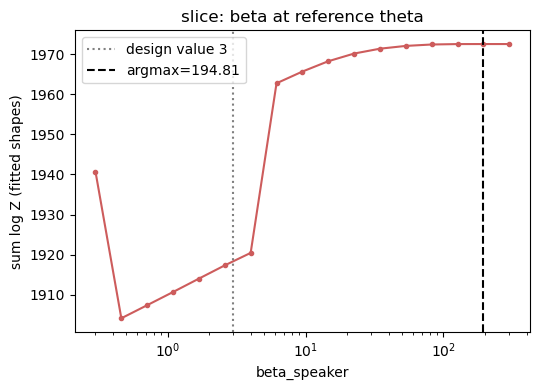

In [2]:
REF_LS, REF_MU, REF_SIGMA = 0.4, 0.0, 1.5
beta_grid = np.geomspace(0.3, 300.0, 17)
ll_beta_f = np.array([inf.total_log_lik_free_shapes(geom, responses_cond,
                                                    REF_LS, REF_MU, REF_SIGMA, beta_speaker=b)
                      for b in beta_grid])

plt.figure(figsize=(5.5, 4))
plt.plot(beta_grid, ll_beta_f, '-o', ms=3, color='indianred')
plt.axvline(inf.BETA_SPEAKER, color='gray', ls=':', label='design value 3')
plt.axvline(beta_grid[np.argmax(ll_beta_f)], color='k', ls='--',
            label=f'argmax={beta_grid[np.argmax(ll_beta_f)]:.2f}')
plt.xscale('log'); plt.xlabel('beta_speaker'); plt.ylabel('sum log Z (fitted shapes)')
plt.legend(); plt.title('slice: beta at reference theta'); plt.tight_layout(); plt.show()

## 2. 4-D VBMC, fitted (profiled) linking shapes

Cached to `results/study6prereg-vbmc-laplace-beta/posterior-fitted-shapes.npz`.

In [3]:
# The default 4-D box (UB beta=30) truncates the study-8 posterior: the profile
# likelihood keeps rising past 30 and only saturates around beta ~100-300 (the
# epsilon-noisy speaker's ceiling). Widen the beta coordinate; prior unchanged.
inf.UB_4[3]  = np.log(1000.0)
inf.PUB_4[3] = np.log(300.0)

SAMPLE_KEYS = ('ls_samples', 'mu0_samples', 'sigma_samples', 'beta_samples')

def load_or_fit(path, fit_fn):
    if os.path.exists(path):
        z = np.load(path, allow_pickle=True)
        fit = {k: z[k] for k in SAMPLE_KEYS}
        fit.update(json.loads(str(z['meta'])))
        print(f"loaded cached posterior from {path}  ({fit['convergence_status']})")
    else:
        fit = fit_fn()
        np.savez_compressed(path, **{k: fit[k] for k in SAMPLE_KEYS},
                            meta=json.dumps({k: fit[k] for k in ('elbo', 'func_count',
                                                                 'convergence_status', 'runtime_s')}))
        print(f"saved posterior to {path}")
    return fit

fit_f = load_or_fit(os.path.join(RESULTS_DIR, 'posterior-fitted-shapes.npz'),
                    lambda: inf.run_vbmc_free_shapes_beta(geom, responses_cond, max_evals=MAX_EVALS))

Reshaping x0 to row vector.


Reshaping lower bounds to (1, 4).


Reshaping upper bounds to (1, 4).


Reshaping plausible lower bounds to (1, 4).


Reshaping plausible upper bounds to (1, 4).


...

    42        220        1975.60         0.16         0.00       24      0.244     stable


   inf        220        1975.66         0.16         0.03       50      0.244     finalize


Inference terminated: variational solution stable for options.tol_stable_count fcn evaluations.


Estimated ELBO: 1975.658 +/-0.165.


saved posterior to results/study6prereg-vbmc-laplace-beta/posterior-fitted-shapes.npz


## 3. Posterior marginals

convergence=probable  evals=220  ELBO=1975.7  runtime=54 min
length_scale    1.794 [0.852, 3.253]
mu_0            0.127 [-0.204, 0.206]
sigma           2.079 [1.394, 3.140]
beta_speaker   29.071 [14.718, 75.992]


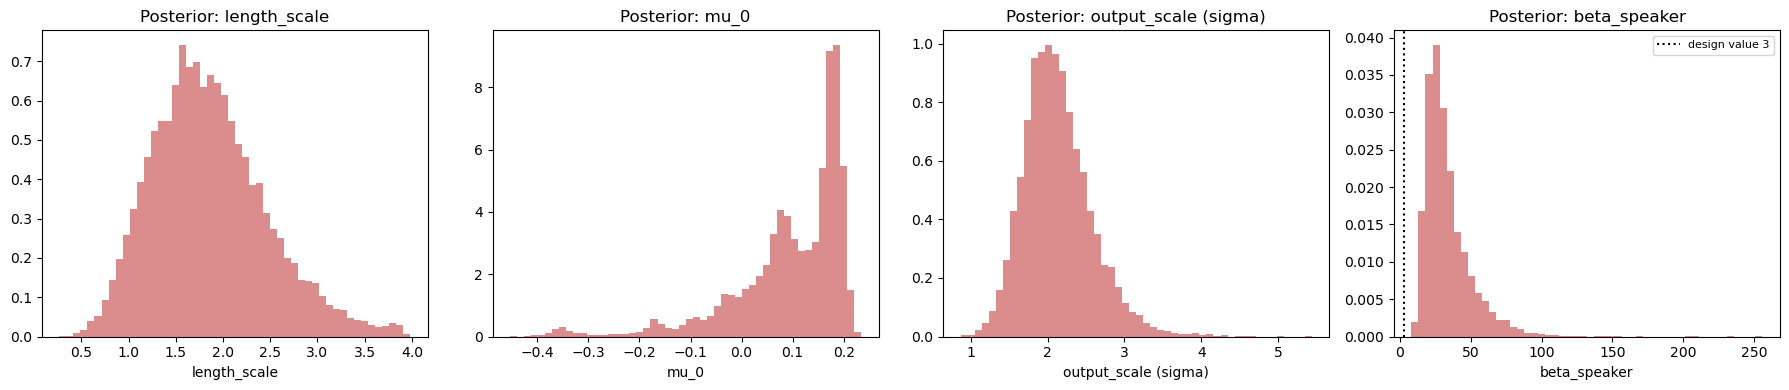

In [4]:
print(f"convergence={fit_f['convergence_status']}  evals={fit_f['func_count']}  "
      f"ELBO={fit_f['elbo']:.1f}  runtime={fit_f['runtime_s']/60:.0f} min")
def fmt(s): return f"{np.median(s):7.3f} [{np.percentile(s,2.5):.3f}, {np.percentile(s,97.5):.3f}]"
for name, key in [('length_scale', 'ls_samples'), ('mu_0', 'mu0_samples'),
                  ('sigma', 'sigma_samples'), ('beta_speaker', 'beta_samples')]:
    print(f"{name:<14}{fmt(fit_f[key])}")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, key, name in zip(axes, ['ls_samples', 'mu0_samples', 'sigma_samples', 'beta_samples'],
                         ['length_scale', 'mu_0', 'output_scale (sigma)', 'beta_speaker']):
    ax.hist(fit_f[key], bins=50, density=True, color='indianred', alpha=0.7)
    if key == 'beta_samples':
        ax.axvline(inf.BETA_SPEAKER, color='k', ls=':', label='design value 3'); ax.legend(fontsize=8)
    ax.set_xlabel(name); ax.set_title(f'Posterior: {name}')
plt.tight_layout(); plt.show()

## 4. Forward pass at the posterior median

Per-feature predictions under two coherence readouts:

- **ratings-free** (`pred_prior`): Laplace mode of GP + utterances only — the model's pure
  prediction for each condition, never having seen the test ratings;
- **ratings-conditioned** (`pred_posterior`): mode of the full posterior including ratings
  (the study 9 section-5 convention).

Both use the fitted per-feature linking shapes at the posterior-median theta.

In [5]:
LS_B, MU_B, SIG_B, BETA_B = (float(np.median(fit_f['ls_samples'])), float(np.median(fit_f['mu0_samples'])),
                             float(np.median(fit_f['sigma_samples'])), float(np.median(fit_f['beta_samples'])))
print(f"Posterior median: ls={LS_B:.3f}, mu_0={MU_B:.3f}, sigma={SIG_B:.3f}, beta={BETA_B:.3f}")

_, shapes_f, cond_data_f = inf.total_log_lik_free_shapes(
    geom, responses_cond, LS_B, MU_B, SIG_B, beta_speaker=BETA_B, return_shapes=True)
mean_kl  = shapes_f[:, 0] / (shapes_f[:, 0] + shapes_f[:, 1])
mean_nkl = shapes_f[:, 2] / (shapes_f[:, 2] + shapes_f[:, 3])
np.savez_compressed(os.path.join(RESULTS_DIR, 'fitted-link-shapes.npz'),
                    shapes=shapes_f, feature_names=np.array(test_feature_names),
                    theta=np.array([LS_B, MU_B, SIG_B, BETA_B]))

pz1_prior = inf.prior_pz1_modes(geom, LS_B, MU_B, SIG_B, beta_speaker=BETA_B)
pred_prior, pred_post = {}, {}
for c in CONDS:
    _, y_hat, ok = inf.laplace_log_Z(cond_data_f[c], LS_B, MU_B, SIG_B, beta_speaker=BETA_B)
    pz1_post = 1.0 / (1.0 + np.exp(-y_hat[:J]))
    pred_post[c]  = pz1_post * mean_kl + (1 - pz1_post) * mean_nkl
    pred_prior[c] = np.asarray(pz1_prior[c]) * mean_kl + (1 - np.asarray(pz1_prior[c])) * mean_nkl
    if not ok:
        print(f"  warning: {c} Laplace mode not cleanly converged")

pred_df = pd.DataFrame([
    {'condition': c, 'feature': f, 'empirical_mean': float(emp_cond[c][j]),
     'pz1_prior': float(pz1_prior[c][j]),
     'pred_prior': float(pred_prior[c][j]), 'pred_posterior': float(pred_post[c][j])}
    for c in CONDS for j, f in enumerate(test_feature_names)])
pred_df.to_csv(os.path.join(RESULTS_DIR, 'predictions.csv'), index=False)
print(f"saved per-feature predictions to {RESULTS_DIR}/predictions.csv")

Posterior median: ls=1.794, mu_0=0.127, sigma=2.079, beta=29.071


saved per-feature predictions to results/study6prereg-vbmc-laplace-beta/predictions.csv


## 5. Predicted vs empirical prevalence per condition

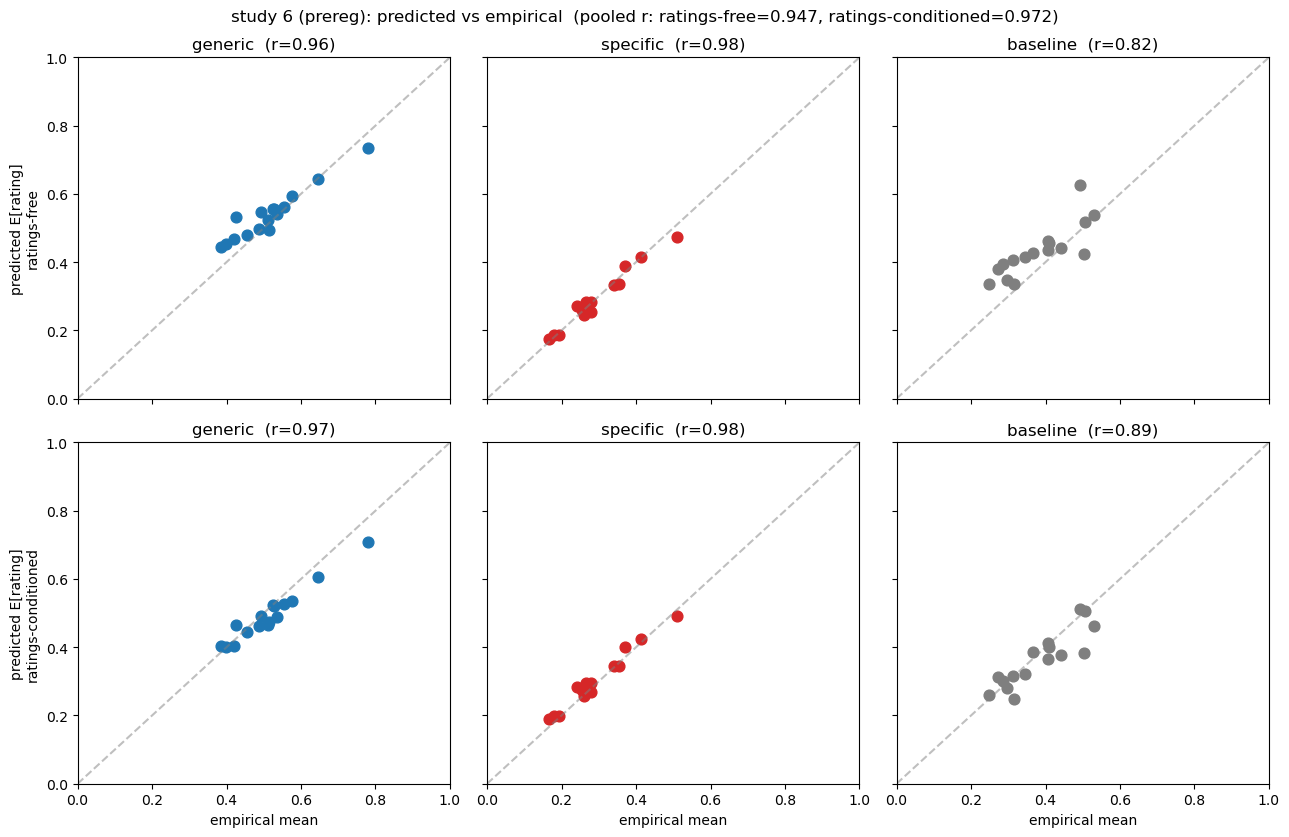

In [6]:
ccol = {'generic': 'tab:blue', 'specific': 'tab:red', 'baseline': 'tab:gray'}
fig, axes = plt.subplots(2, 3, figsize=(13, 8.5), sharex=True, sharey=True)
for row, (pred, lbl) in enumerate([(pred_prior, 'ratings-free'),
                                   (pred_post, 'ratings-conditioned')]):
    for ax, c in zip(axes[row], CONDS):
        ax.scatter(emp_cond[c], pred[c], s=60, color=ccol[c])
        ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        r = np.corrcoef(emp_cond[c], pred[c])[0, 1]
        ax.set_title(f"{c}  (r={r:.2f})")
        if row == 1: ax.set_xlabel('empirical mean')
    axes[row][0].set_ylabel(f"predicted E[rating]\n{lbl}")
cat = lambda pred: np.concatenate([pred[c] for c in CONDS])
r_prior = np.corrcoef(cat(emp_cond), cat(pred_prior))[0, 1]
r_post  = np.corrcoef(cat(emp_cond), cat(pred_post))[0, 1]
fig.suptitle(f'study 6 (prereg): predicted vs empirical  (pooled r: ratings-free={r_prior:.3f}, '
             f'ratings-conditioned={r_post:.3f})')
plt.tight_layout(); plt.show()

## 6. Condition means

The headline manipulation check: generic training should raise rated prevalence of the
(unmentioned) test features relative to baseline, specific training should lower it.

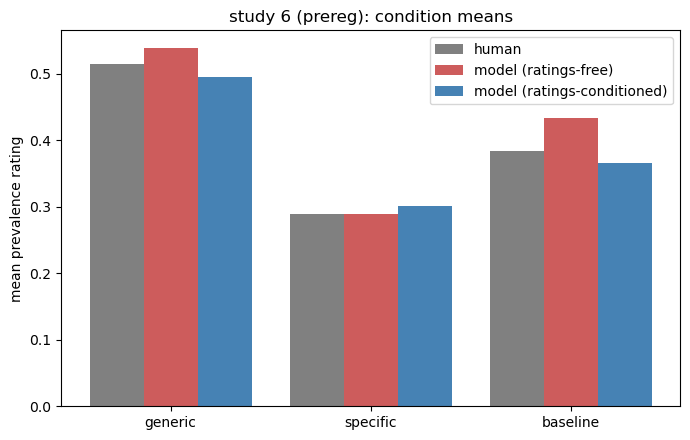

In [7]:
x = np.arange(len(CONDS)); w = 0.27
emp_m = [float(np.array(responses_cond[c]).mean()) for c in CONDS]
pri_m = [float(pred_prior[c].mean()) for c in CONDS]
pos_m = [float(pred_post[c].mean()) for c in CONDS]
plt.figure(figsize=(7, 4.5))
plt.bar(x - w, emp_m, w, label='human', color='gray')
plt.bar(x,     pri_m, w, label='model (ratings-free)', color='indianred')
plt.bar(x + w, pos_m, w, label='model (ratings-conditioned)', color='steelblue')
plt.xticks(x, CONDS); plt.ylabel('mean prevalence rating'); plt.legend()
plt.title('study 6 (prereg): condition means'); plt.tight_layout(); plt.show()

## 7. GP coherence field per condition at the posterior median

Same visualization as `plot-gp-coherence-field.ipynb` / study 9 section 6: contours are the
ratings-free GP-conditional `P(kind-linked)` given each condition's training utterances, at the
posterior-median theta. Generic-trained features pull the field up (dark circles), specific-trained
features pull it down (red X's), baseline is the bare prior `sigmoid(mu_0)`. Test features are
colored by their empirical mean rating on the same 0-1 color scale.

Top row: absolute 0-1 scale (comparable across conditions). Bottom row: per-panel autoscaled
contours — with the fitted length scale (~2.5) far exceeding the feature-cloud diameter (~0.8)
the field is nearly flat within a condition, so spatial structure only shows up once autoscaled.

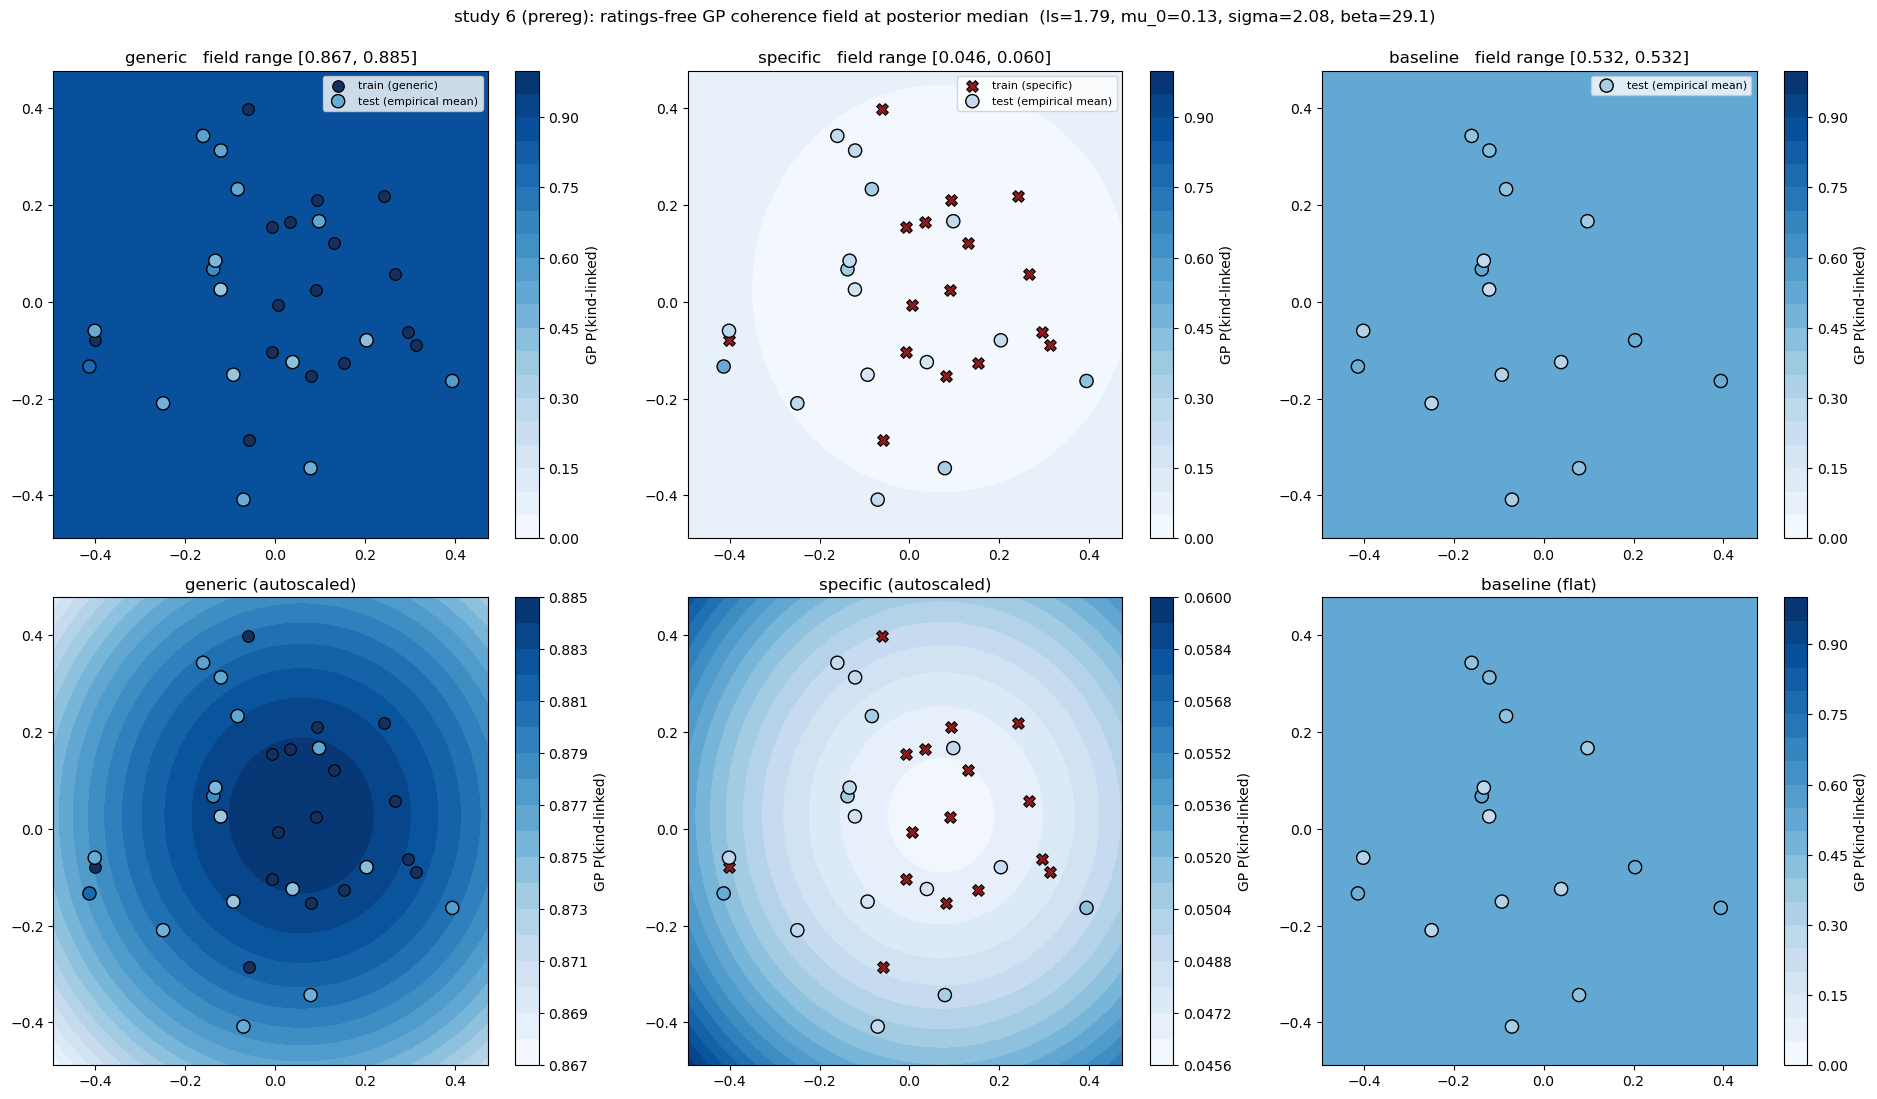

generic   field at test features: mean=0.882  range [0.877, 0.884]


specific  field at test features: mean=0.048  range [0.047, 0.052]
baseline  field at test features: mean=0.532  range [0.532, 0.532]


In [8]:
all_x = np.vstack([np.array(geom['x_test'])] +
                  [np.array(geom['x_train_cond'][c]) for c in CONDS])
pad = 0.08
(x_lo, y_lo), (x_hi, y_hi) = all_x.min(0) - pad, all_x.max(0) + pad
gx, gy = np.meshgrid(np.linspace(x_lo, x_hi, 80), np.linspace(y_lo, y_hi, 80))
X_grid = np.column_stack([gx.ravel(), gy.ravel()])
x_test_np = np.array(geom['x_test'])

fields = {c: inf.gp_coherence_field(geom, c, LS_B, MU_B, SIG_B, X_grid,
                                    beta_speaker=BETA_B).reshape(gx.shape) for c in CONDS}

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
for col, c in enumerate(CONDS):
    field = fields[c]
    for row in range(2):
        ax = axes[row, col]
        flat = field.max() - field.min() < 1e-6   # baseline: no utterances -> exactly flat
        levels = np.linspace(0, 1, 21) if (row == 0 or flat) else 20
        cs = ax.contourf(gx, gy, field, levels=levels, cmap='Blues')
        cb = fig.colorbar(cs, ax=ax); cb.set_label('GP P(kind-linked)')

        x_tr = np.array(geom['x_train_cond'][c])
        if len(x_tr):
            u = np.array(geom['u_train_cond'][c])
            style = {0: ('o', '#16305e', 'train (generic)'),
                     1: ('X', '#8c1a1a', 'train (specific)')}
            for uu in np.unique(u):
                m = u == uu
                ax.scatter(x_tr[m, 0], x_tr[m, 1], s=70, marker=style[uu][0],
                           color=style[uu][1], edgecolor='k', linewidth=0.8,
                           zorder=3, label=style[uu][2])
        ax.scatter(x_test_np[:, 0], x_test_np[:, 1], s=90, c=emp_cond[c],
                   cmap='Blues', vmin=0, vmax=1, edgecolor='k', zorder=4,
                   label='test (empirical mean)')
        ax.set_title(f"{c}   field range [{field.min():.3f}, {field.max():.3f}]"
                     if row == 0 else (f"{c} (flat)" if flat else f"{c} (autoscaled)"))
        if row == 0:
            ax.legend(fontsize=8, loc='upper right')
fig.suptitle(f'study 6 (prereg): ratings-free GP coherence field at posterior median  '
             f'(ls={LS_B:.2f}, mu_0={MU_B:.2f}, sigma={SIG_B:.2f}, beta={BETA_B:.1f})',
             y=0.995)
plt.tight_layout(); plt.show()

for c in CONDS:
    pz1_test = inf.gp_coherence_field(geom, c, LS_B, MU_B, SIG_B, x_test_np, beta_speaker=BETA_B)
    print(f"{c:<9} field at test features: mean={pz1_test.mean():.3f}  "
          f"range [{pz1_test.min():.3f}, {pz1_test.max():.3f}]")

## 8. Model vs data in the Exp-1a format (+ export for the R pipeline)

Same visual language as the slides (`analyses/study 6/study6_analysis.Rmd`):   
x = model prevalence,  
y = human prevalence,  
small dots = the 48 condition x feature cells,  
large dots = condition means,   
r² = squared correlation across cells.  

This GP + RSA model is the analog of the **pragmatic listener**
(the specific-condition suppression comes from speaker-based pragmatic reasoning); the model
prevalences are the **ratings-free** forward predictions.

Also exports `df_gp_feature_prereg.csv` — one row per (condition, feature) with the R pipeline's
snake_case feature names — schema-compatible with the Rmd's `df_prag_feature.csv` import, so
the same `glmmTMB(prevalence ~ model_mean + (1|participant))` AIC/BIC comparison can be run
against the base / literal / pragmatic variants.

Caveat for the comparison: our theta (and beta) were FIT to these ratings, while their model
means may come from forward simulation at hand-set parameters — worth stating alongside AIC/BIC.

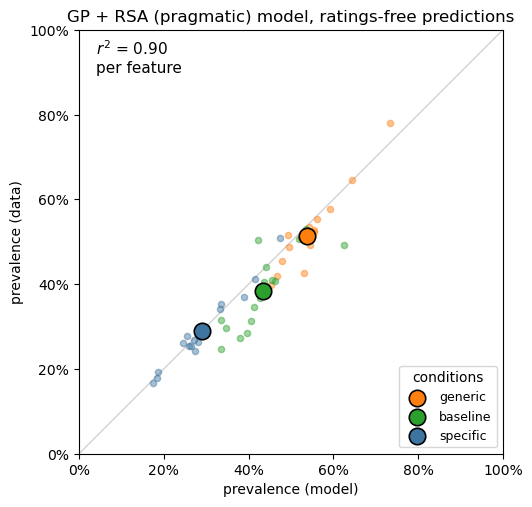

  generic   r2 per feature (within condition) = 0.91
  baseline  r2 per feature (within condition) = 0.67
  specific  r2 per feature (within condition) = 0.97
saved df_gp_feature_prereg.csv to results/study6prereg-vbmc-laplace-beta/ and ../scratch/study 6/


In [9]:
COND_ORDER = ['generic', 'baseline', 'specific']
COND_COLOR = {'generic': 'tab:orange', 'baseline': 'tab:green', 'specific': '#3d74a0'}

fig, ax = plt.subplots(figsize=(5.4, 5.4))
ax.plot([0, 1], [0, 1], color='lightgray', lw=1, zorder=0)
for c in COND_ORDER:
    ax.scatter(pred_prior[c], emp_cond[c], s=20, color=COND_COLOR[c], alpha=0.45, zorder=2)
    ax.scatter(pred_prior[c].mean(), emp_cond[c].mean(), s=140, color=COND_COLOR[c],
               edgecolor='k', linewidth=1.2, zorder=3, label=c)
allx = np.concatenate([pred_prior[c] for c in COND_ORDER])
ally = np.concatenate([emp_cond[c] for c in COND_ORDER])
r2 = np.corrcoef(allx, ally)[0, 1] ** 2
ax.text(0.04, 0.90, f"$r^2$ = {r2:.2f}\nper feature", transform=ax.transAxes, fontsize=11)
ticks = np.linspace(0, 1, 6)
ax.set_xticks(ticks); ax.set_yticks(ticks)
ax.set_xticklabels([f'{t:.0%}' for t in ticks]); ax.set_yticklabels([f'{t:.0%}' for t in ticks])
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.set_xlabel('prevalence (model)'); ax.set_ylabel('prevalence (data)')
ax.legend(title='conditions', fontsize=9, loc='lower right')
ax.set_title('GP + RSA (pragmatic) model, ratings-free predictions')
plt.tight_layout(); plt.show()

for c in COND_ORDER:
    r2c = np.corrcoef(pred_prior[c], emp_cond[c])[0, 1] ** 2
    print(f"  {c:<9} r2 per feature (within condition) = {r2c:.2f}")

# export for the R pipeline (schema of model/scratch/study 6/df_prag_feature.csv:
# columns condition, feature, prevalence; the Rmd averages over rows per cell,
# so one row per condition x feature carrying the model mean is equivalent)
col_of_feature = {v: k for k, v in s68.STUDY6_COL_TO_FEATURE.items()}
export = pd.DataFrame([
    {'condition': c, 'feature': col_of_feature[f], 'prevalence': float(pred_prior[c][j])}
    for c in COND_ORDER for j, f in enumerate(test_feature_names)])
export.to_csv(os.path.join(RESULTS_DIR, 'df_gp_feature_prereg.csv'), index=False)
scratch_dir = os.path.join('..', 'scratch', 'study 6')
os.makedirs(scratch_dir, exist_ok=True)
export.to_csv(os.path.join(scratch_dir, 'df_gp_feature_prereg.csv'), index=False)
print(f"saved df_gp_feature_prereg.csv to {RESULTS_DIR}/ and {scratch_dir}/")